<a href="https://colab.research.google.com/github/rotoncsedu/Computer-Vision/blob/main/Oxford_Pet_data_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!wget http://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz
!wget http://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz

--2026-04-18 17:22:11--  http://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz
Resolving www.robots.ox.ac.uk (www.robots.ox.ac.uk)... 129.67.94.2
Connecting to www.robots.ox.ac.uk (www.robots.ox.ac.uk)|129.67.94.2|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz [following]
--2026-04-18 17:22:12--  https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz
Connecting to www.robots.ox.ac.uk (www.robots.ox.ac.uk)|129.67.94.2|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://thor.robots.ox.ac.uk/pets/images.tar.gz [following]
--2026-04-18 17:22:12--  https://thor.robots.ox.ac.uk/pets/images.tar.gz
Resolving thor.robots.ox.ac.uk (thor.robots.ox.ac.uk)... 129.67.95.98
Connecting to thor.robots.ox.ac.uk (thor.robots.ox.ac.uk)|129.67.95.98|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 791918971 (755M) [app

In [2]:
!tar -xvf images.tar.gz
!tar -xvf annotations.tar.gz

Streaming output truncated to the last 5000 lines.
annotations/trimaps/._pomeranian_180.png
annotations/trimaps/pomeranian_180.png
annotations/trimaps/._pomeranian_181.png
annotations/trimaps/pomeranian_181.png
annotations/trimaps/._pomeranian_182.png
annotations/trimaps/pomeranian_182.png
annotations/trimaps/._pomeranian_183.png
annotations/trimaps/pomeranian_183.png
annotations/trimaps/._pomeranian_184.png
annotations/trimaps/pomeranian_184.png
annotations/trimaps/._pomeranian_185.png
annotations/trimaps/pomeranian_185.png
annotations/trimaps/._pomeranian_186.png
annotations/trimaps/pomeranian_186.png
annotations/trimaps/._pomeranian_187.png
annotations/trimaps/pomeranian_187.png
annotations/trimaps/._pomeranian_188.png
annotations/trimaps/pomeranian_188.png
annotations/trimaps/._pomeranian_189.png
annotations/trimaps/pomeranian_189.png
annotations/trimaps/._pomeranian_19.png
annotations/trimaps/pomeranian_19.png
annotations/trimaps/._pomeranian_190.png
annotations/trimaps/pomeranian

In [3]:
input_dir = 'images/'
output_dir = "annotations/trimaps/"

In [4]:
import os

input_img_paths = sorted(
    [os.path.join(input_dir, fname) for fname in os.listdir(input_dir)
    if fname.endswith(".jpg")]
)
target_img_paths = sorted(
    [
        os.path.join(output_dir, fname)
        for fname in os.listdir(output_dir)
        if fname.endswith(".png") and not fname.startswith(".")]
)

In [5]:
input_img_paths[:5]

['images/Abyssinian_1.jpg',
 'images/Abyssinian_10.jpg',
 'images/Abyssinian_100.jpg',
 'images/Abyssinian_101.jpg',
 'images/Abyssinian_102.jpg']

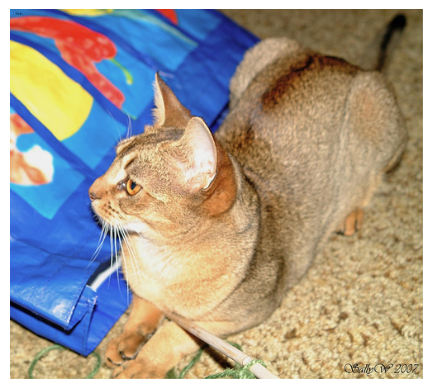

In [6]:
import matplotlib.pyplot as plt
from tensorflow.keras.utils import load_img, img_to_array
plt.axis("off")
plt.imshow(load_img(input_img_paths[9]))

[[127 127 127 ... 127 127 127]
 [127 127 127 ... 127 127 127]
 [127 127 127 ... 127 127 127]
 ...
 [127 127 127 ... 127 127 127]
 [127 127 127 ... 127 127 127]
 [127 127 127 ... 127 127 127]]


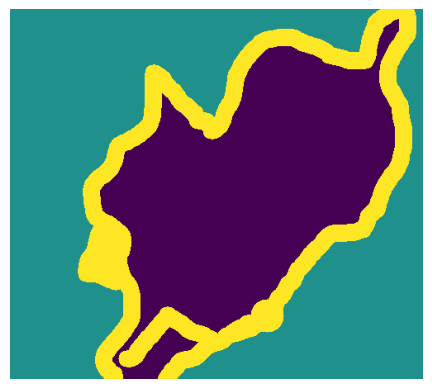

In [7]:
def display_target(target_array):
    normalized_array = (target_array.astype("uint8") - 1) * 127
    print(normalized_array[:, :, 0])
    plt.imshow(normalized_array[:, :, 0])
    plt.axis("off")

img = img_to_array(load_img(target_img_paths[9]))
display_target(img)
# print(img)


In [8]:
import numpy as np
import random

img_size = (200,200)
num_imgs = len(input_img_paths)

random.Random(1337).shuffle(input_img_paths)
random.Random(1337).shuffle(target_img_paths)

def path_to_input_image(path):
  return img_to_array(load_img(path, target_size=img_size))

def path_to_target_image(path):
  img = load_img(path, target_size=img_size, color_mode="grayscale")
  img = img_to_array(img)
  img = img.astype("uint8") - 1  # Subtract 1 to shift labels from [1,2,3] to [0,1,2]
  return img

In [16]:
input_images = np.zeros((num_imgs,) + img_size + (3,), dtype="float32")
target_images = np.zeros((num_imgs,) + img_size + (1,), dtype="uint8")

for i in range(num_imgs):
  input_images[i] = path_to_input_image(input_img_paths[i])
  target_images[i] = path_to_target_image(target_img_paths[i])

num_val_samples = 1000
train_input_imgs = input_images[:-num_val_samples]
train_target_imgs = target_images[:-num_val_samples]
val_input_imgs = input_images[-num_val_samples:]
val_target_imgs = target_images[-num_val_samples:]

In [11]:
from tensorflow import keras
from tensorflow.keras import layers

def get_model(img_size, num_classes):
  inputs = keras.Input(shape=img_size + (3,))
  x = layers.Rescaling(1./255)(inputs)

  x = layers.Conv2D(64, 3, strides=2, activation="relu", padding="same")(x)
  x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
  x = layers.Conv2D(128, 3, strides=2, activation="relu", padding="same")(x)
  x = layers.Conv2D(128, 3, activation="relu", padding="same")(x)
  x = layers.Conv2D(256, 3, strides=2, padding="same", activation="relu")(x)
  x = layers.Conv2D(256, 3, activation="relu", padding="same")(x)

  x = layers.Conv2DTranspose(256, 3, activation="relu", padding="same")(x)
  x = layers.Conv2DTranspose(256, 3, strides=2, activation="relu", padding="same")(x)
  x = layers.Conv2DTranspose(128, 3, activation="relu", padding="same")(x)
  x = layers.Conv2DTranspose(128, 3, strides=2, activation="relu", padding="same")(x)
  x = layers.Conv2DTranspose(64, 3, activation="relu", padding="same")(x)
  x = layers.Conv2DTranspose(64, 3, strides=2, activation="relu", padding="same")(x)

  outputs = layers.Conv2D(num_classes, 3, activation="softmax", padding="same")(x)

  model = keras.Model(inputs, outputs)
  return model

model = get_model(img_size, 3)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 200, 200, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 200, 200, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 100, 100, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 100, 100, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 50, 50, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 50, 50, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 25, 25, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 25, 25, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 25, 25, 256)    │       590,080 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 50, 50, 256)    │       590,080 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 50, 50, 128)    │       295,040 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 100, 100, 128)  │       147,584 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_4              │ (None, 100, 100, 64)   │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_5              │ (None, 200, 200, 64)   │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 200, 200, 3)    │         1,731 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,880,643 (10.99 MB)

 Trainable params: 2,880,643 (10.99 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
model.compile(optimizer="rmsprop", loss="sparse_categorical_crossentropy")
callbacks = [
    keras.callbacks.ModelCheckpoint("oxford_segmentation.keras", save_best_only=True)
]

In [13]:
history = model.fit(
    train_input_imgs,
    train_target_imgs,
    batch_size=64,
    epochs=15,
    validation_data=(val_input_imgs, val_target_imgs),
    callbacks=callbacks,
)

Epoch 1/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 181s 1s/step - loss: 0.9473 - val_loss: 0.9022
Epoch 2/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 61s 607ms/step - loss: 0.8865 - val_loss: 0.8898
Epoch 3/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 61s 605ms/step - loss: 0.8377 - val_loss: 0.8135
Epoch 4/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 60s 602ms/step - loss: 0.8220 - val_loss: 0.7844
Epoch 5/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 60s 600ms/step - loss: 0.7868 - val_loss: 0.8549
Epoch 6/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 60s 602ms/step - loss: 0.7714 - val_loss: 0.7448
Epoch 7/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 60s 602ms/step - loss: 0.7555 - val_loss: 0.7868
Epoch 8/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 60s 603ms/step - loss: 0.7419 - val_loss: 0.7077
Epoch 9/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 60s 604ms/step - loss: 0.7264 - val_loss: 0.8191
Epoch 10/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 61s 609ms/step - loss: 0.6997 - val_loss: 0.7326
Epoch 11/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 61s 610ms/step - loss: 0.6786 - val_loss: 0.6888
Epoch 12/15
100/100 ━

<function matplotlib.pyplot.show(close=None, block=None)>

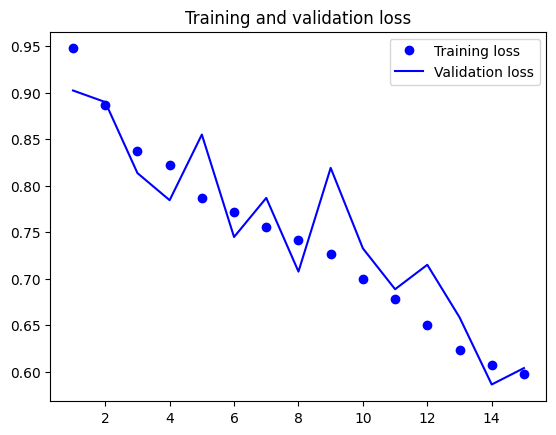

In [14]:
epochs = range(1, len(history.history["loss"]) + 1)
loss = history.history["loss"]
val_loss = history.history["val_loss"]
plt.figure()
plt.plot(epochs, loss, "b", label="Training loss")
plt.plot(epochs, val_loss, "r", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show

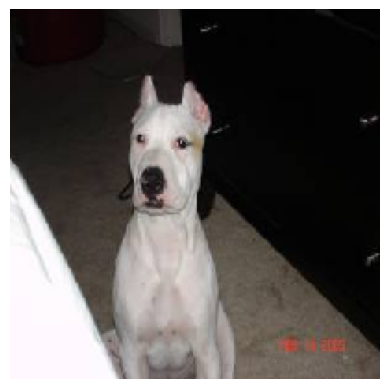

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   


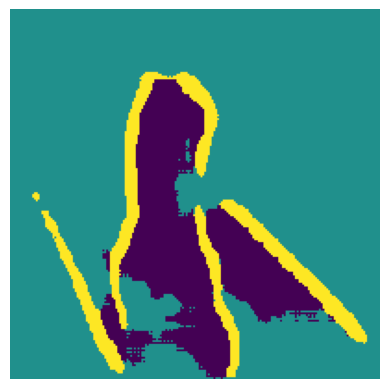

In [17]:
from tensorflow.keras.utils import array_to_img

model = keras.models.load_model("oxford_segmentation.keras")

i = 4
test_img = val_input_imgs[i]
plt.axis("off")
plt.imshow(test_img.astype("uint8"))
plt.show()

mask = model.predict(np.expand_dims(test_img, 0))[0]
def display_mask(input_mask_array):
  processed_mask = np.argmax(input_mask_array, axis=-1)
  processed_mask *= 127
  plt.axis("off")
  plt.imshow(processed_mask)

display_mask(mask)

In [19]:
img_size

(200, 200)

In [22]:
from tensorflow import keras
from tensorflow.keras import layers


# Encoder residual block
def residual_block(x, filters, stride=1):

    shortcut = x

    # Main path
    x = layers.Conv2D(filters, 3,
                      strides=stride,
                      padding="same")(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(filters, 3,
                      padding="same")(x)

    # Projection shortcut if needed
    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters,
                                 1,
                                 strides=stride,
                                 padding="same")(shortcut)

    # Residual addition
    x = layers.Add()([x, shortcut])

    x = layers.ReLU()(x)

    return x


# Decoder residual block
def residual_up_block(x, filters, stride=1):

    shortcut = x

    # Main path
    x = layers.Conv2DTranspose(filters, 3,
                               padding="same")(x)
    x = layers.ReLU()(x)

    x = layers.Conv2DTranspose(filters, 3,
                               strides=stride,
                               padding="same")(x)

    # Projection shortcut for upsampling
    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2DTranspose(
            filters,
            1,
            strides=stride,
            padding="same"
        )(shortcut)

    x = layers.Add()([x, shortcut])

    x = layers.ReLU()(x)

    return x


def get_model(img_size, num_classes):

    inputs = keras.Input(shape=img_size + (3,))
    print(img_size)
    print(inputs)
    x = layers.Rescaling(1./255)(inputs)

    # Encoder
    x = residual_block(x, 64, stride=2)
    x = residual_block(x, 128, stride=2)
    x = residual_block(x, 256, stride=2)

    # Decoder
    x = residual_up_block(x, 256, stride=2)
    x = residual_up_block(x, 128, stride=2)
    x = residual_up_block(x, 64, stride=2)

    outputs = layers.Conv2D(
        num_classes,
        3,
        activation="softmax",
        padding="same"
    )(x)

    model = keras.Model(inputs, outputs)

    return model


model = get_model((200,200), 3)

model.summary()

(200, 200)
<KerasTensor shape=(None, 200, 200, 3), dtype=float32, sparse=False, ragged=False, name=keras_tensor_188>


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 200, 200,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_4         │ (None, 200, 200,  │          0 │ input_layer_4[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_37 (Conv2D)  │ (None, 100, 100,  │      1,792 │ rescaling_4[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_36 (ReLU)     │ (None, 100, 100,  │          0 │ conv2d_37[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_38 (Conv2D)  │ (None, 100, 100,  │     36,928 │ re_lu_36[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_39 (Conv2D)  │ (None, 100, 100,  │        256 │ rescaling_4[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_18 (Add)        │ (None, 100, 100,  │          0 │ conv2d_38[0][0],  │
│                     │ 64)               │            │ conv2d_39[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_37 (ReLU)     │ (None, 100, 100,  │          0 │ add_18[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_40 (Conv2D)  │ (None, 50, 50,    │     73,856 │ re_lu_37[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_38 (ReLU)     │ (None, 50, 50,    │          0 │ conv2d_40[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_41 (Conv2D)  │ (None, 50, 50,    │    147,584 │ re_lu_38[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_42 (Conv2D)  │ (None, 50, 50,    │      8,320 │ re_lu_37[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_19 (Add)        │ (None, 50, 50,    │          0 │ conv2d_41[0][0],  │
│                     │ 128)              │            │ conv2d_42[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_39 (ReLU)     │ (None, 50, 50,    │          0 │ add_19[0][0]      │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_43 (Conv2D)  │ (None, 25, 25,    │    295,168 │ re_lu_39[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_40 (ReLU)     │ (None, 25, 25,    │          0 │ conv2d_43[0][0]   │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_44 (Conv2D)  │ (None, 25, 25,    │    590,080 │ re_lu_40[0][0]  

 Total params: 3,029,187 (11.56 MB)

 Trainable params: 3,029,187 (11.56 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
model.compile(optimizer="rmsprop", loss="sparse_categorical_crossentropy")
callbacks = [
    keras.callbacks.ModelCheckpoint("oxford_segmentation.keras", save_best_only=True)
]

In [24]:
history = model.fit(
    train_input_imgs,
    train_target_imgs,
    batch_size=64,
    epochs=15,
    validation_data=(val_input_imgs, val_target_imgs),
    callbacks=callbacks,
)

Epoch 1/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 123s 998ms/step - loss: 0.9377 - val_loss: 0.8835
Epoch 2/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 69s 692ms/step - loss: 0.8864 - val_loss: 0.8087
Epoch 3/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 70s 696ms/step - loss: 0.8181 - val_loss: 0.7529
Epoch 4/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 70s 698ms/step - loss: 0.7981 - val_loss: 0.7412
Epoch 5/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 69s 695ms/step - loss: 0.7625 - val_loss: 0.7450
Epoch 6/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 70s 699ms/step - loss: 0.7187 - val_loss: 0.6742
Epoch 7/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 70s 699ms/step - loss: 0.6704 - val_loss: 0.6082
Epoch 8/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 70s 698ms/step - loss: 0.6438 - val_loss: 0.6358
Epoch 9/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 70s 699ms/step - loss: 0.6176 - val_loss: 0.5754
Epoch 10/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 70s 698ms/step - loss: 0.5987 - val_loss: 0.5650
Epoch 11/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 70s 698ms/step - loss: 0.5789 - val_loss: 0.5298
Epoch 12/15
100/10

<function matplotlib.pyplot.show(close=None, block=None)>

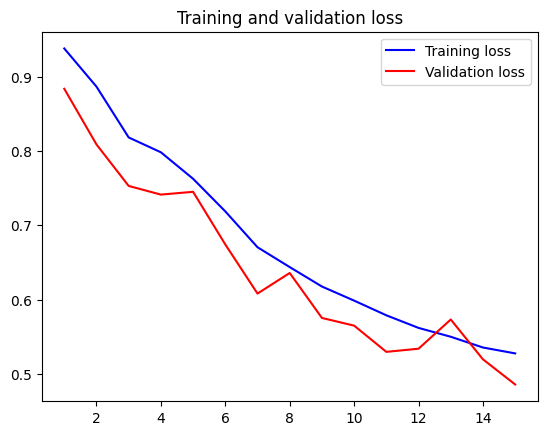

In [25]:
epochs = range(1, len(history.history["loss"]) + 1)
loss = history.history["loss"]
val_loss = history.history["val_loss"]
plt.figure()
plt.plot(epochs, loss, "b", label="Training loss")
plt.plot(epochs, val_loss, "r", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show

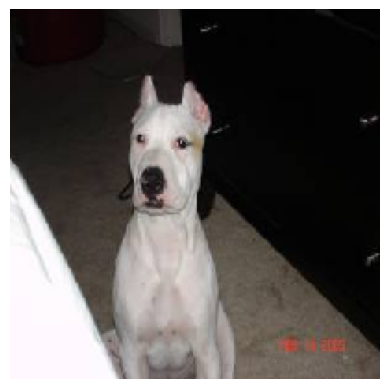

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


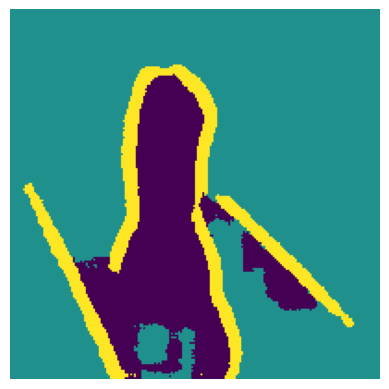

In [26]:
from tensorflow.keras.utils import array_to_img

model = keras.models.load_model("oxford_segmentation.keras")

i = 4
test_img = val_input_imgs[i]
plt.axis("off")
plt.imshow(test_img.astype("uint8"))
plt.show()

mask = model.predict(np.expand_dims(test_img, 0))[0]
def display_mask(input_mask_array):
  processed_mask = np.argmax(input_mask_array, axis=-1)
  processed_mask *= 127
  plt.axis("off")
  plt.imshow(processed_mask)

display_mask(mask)